# Explainable AI (XAI) com SHAP
Utilizando o framework SHAP (SHapley Additive exPlanations) com objetivo de validar quais variáveis (sensores e condições de voo) a rede neural considera mais importantes para prever a vida útil (RUL), validando se o aprendizado do modelo tem sentido físico e termodinâmico.

In [1]:
import os
import h5py
import gc
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

import tensorflow as tf
from tensorflow.keras.models import load_model

# Configuração Padrão IEEE para os gráficos
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 8
plt.rcParams['ytick.labelsize'] = 8
plt.rcParams['legend.fontsize'] = 8
plt.rcParams['figure.titlesize'] = 12
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

I0000 00:00:1789853904.400087   61416 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789853904.427128   61416 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 1. Carregando Dados e o Melhor Modelo

In [2]:
# Carregando Dados de Teste
filename = '../data/N-CMAPSS_DS02-006.h5'
if not os.path.exists(filename):
    filename = 'data/N-CMAPSS_DS02-006.h5'

with h5py.File(filename, 'r') as hdf:
    W_test = np.array(hdf.get('W_test'))
    X_s_test = np.array(hdf.get('X_s_test'))
    Y_test = np.array(hdf.get('Y_test'))
    A_test = np.array(hdf.get('A_test'))
    
    W_var = [v.decode('utf-8') for v in np.array(hdf.get('W_var'))]
    X_s_var = [v.decode('utf-8') for v in np.array(hdf.get('X_s_var'))]

# Reconstruindo os nomes das features temporais
base_names = W_var + X_s_var
feature_names = [f"{name}_raw" for name in base_names] + \
                [f"{name}_mean" for name in base_names] + \
                [f"{name}_var" for name in base_names]

def create_temporal_features_safe(W, X_s, Y, A, window):
    matriz_base = np.concatenate((W, X_s), axis=1).astype('float32')
    df = pd.DataFrame(matriz_base)
    df['unit'] = A[:, 0].astype('float32')
    df['RUL'] = Y.flatten().astype('float32')

    df_mean = df.groupby('unit').rolling(window=window, min_periods=1).mean().reset_index(level=0, drop=True).sort_index().astype('float32')
    df_var = df.groupby('unit').rolling(window=window, min_periods=1).var().fillna(0).reset_index(level=0, drop=True).sort_index().astype('float32')

    df_mean = df_mean[df.columns[:-2]]
    df_var = df_var[df.columns[:-2]]
    df_raw = pd.DataFrame(matriz_base)

    X_temporal = pd.concat([df_raw, df_mean, df_var], axis=1).values.astype('float32')
    y_labels = df['RUL'].values.astype('float32')

    del df, df_mean, df_var, df_raw, matriz_base
    gc.collect()

    return X_temporal, y_labels

# Substitua 'model' pela pasta do seu melhor modelo
MODEL_FOLDER = 'model'
WINDOW_SIZE = 20 

print(f"Carregando {MODEL_FOLDER}...")
model = load_model(os.path.join(MODEL_FOLDER, 'model.keras'))
scaler = joblib.load(os.path.join(MODEL_FOLDER, 'scaler.pkl'))

X_test_raw, y_test_labels = create_temporal_features_safe(W_test, X_s_test, Y_test, A_test, window=WINDOW_SIZE)
X_test_scaled = scaler.transform(X_test_raw).astype('float32')

df_X_test = pd.DataFrame(X_test_scaled, columns=feature_names)

print("Dados e Modelo carregados com sucesso!")

Carregando model...


I0000 00:00:1789853906.599884   61416 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5743 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a
/home/anderson/miniconda3/envs/intelligent_systems/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Dados e Modelo carregados com sucesso!


## 2. Calculando os Valores SHAP
Como o modelo possui centenas de milhares de amostras, calcular o SHAP para todo o dataset travaria qualquer computador. 
É tomado a decisão de amostrar aleatoriamente um *background* representativo para treinar o explainer, e usar um conjunto de teste menor para gerar o gráfico.

In [3]:
np.random.seed(42)

# Selecionando 500 amostras aleatórias como "Background" (linha de base para o SHAP entender o modelo)
background_idx = np.random.choice(X_test_scaled.shape[0], 500, replace=False)
background_data = X_test_scaled[background_idx]

# Selecionando 1000 amostras para explicar e plotar
explain_idx = np.random.choice(X_test_scaled.shape[0], 1000, replace=False)
explain_data = X_test_scaled[explain_idx]

# Cria o Explainer para Redes Neurais Profundas
print("Construindo DeepExplainer... Isso pode levar alguns minutos.")
# O DeepExplainer suporta modelos tf.keras
explainer = shap.DeepExplainer(model, background_data)

print("Calculando SHAP Values...")
# Usando o check_additivity=False devido a um erro (bug matemático) de compatibilidade 
# entre o SHAP e versões recentes do TensorFlow 2.x com MLPs complexas.
shap_values = explainer.shap_values(explain_data, check_additivity=False)

# No keras moderno, dependendo da versão, shap_values pode vir como lista
if isinstance(shap_values, list):
    shap_values = shap_values[0]

# O Keras geralmente retorna a predição no formato (amostras, 1). 
# Isso faz o SHAP retornar um tensor 3D de formato (amostras, features, 1).
# Precisamos remover essa última dimensão para o gráfico entender as 54 colunas.
if len(np.array(shap_values).shape) == 3:
    shap_values = np.squeeze(shap_values)

print("SHAP values calculados com sucesso!")

Construindo DeepExplainer... Isso pode levar alguns minutos.


/home/anderson/miniconda3/envs/intelligent_systems/lib/python3.11/site-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/home/anderson/miniconda3/envs/intelligent_systems/lib/python3.11/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=['Tensor(shape=(500, 54))']
  warnings.warn(msg)


Calculando SHAP Values...


/home/anderson/miniconda3/envs/intelligent_systems/lib/python3.11/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=['Tensor(shape=(1000, 54))']
  warnings.warn(msg)


SHAP values calculados com sucesso!


## 3. Interpretabilidade Global (Gráfico de Impacto)
**Summary Plot** é o gráfico mais famoso do SHAP. Ele lista as features em ordem de importância de cima para baixo. A cor representa o valor original da feature (Vermelho = Alto, Azul = Baixo), e o eixo X representa o impacto na predição do RUL. Se um ponto vermelho está posicionado do lado esquerdo (eixo X negativo), significa que quando aquela variável está alta, o modelo deduz vida útil do motor (o motor vai quebrar mais cedo).

/tmp/ipykernel_61416/1446976754.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none o

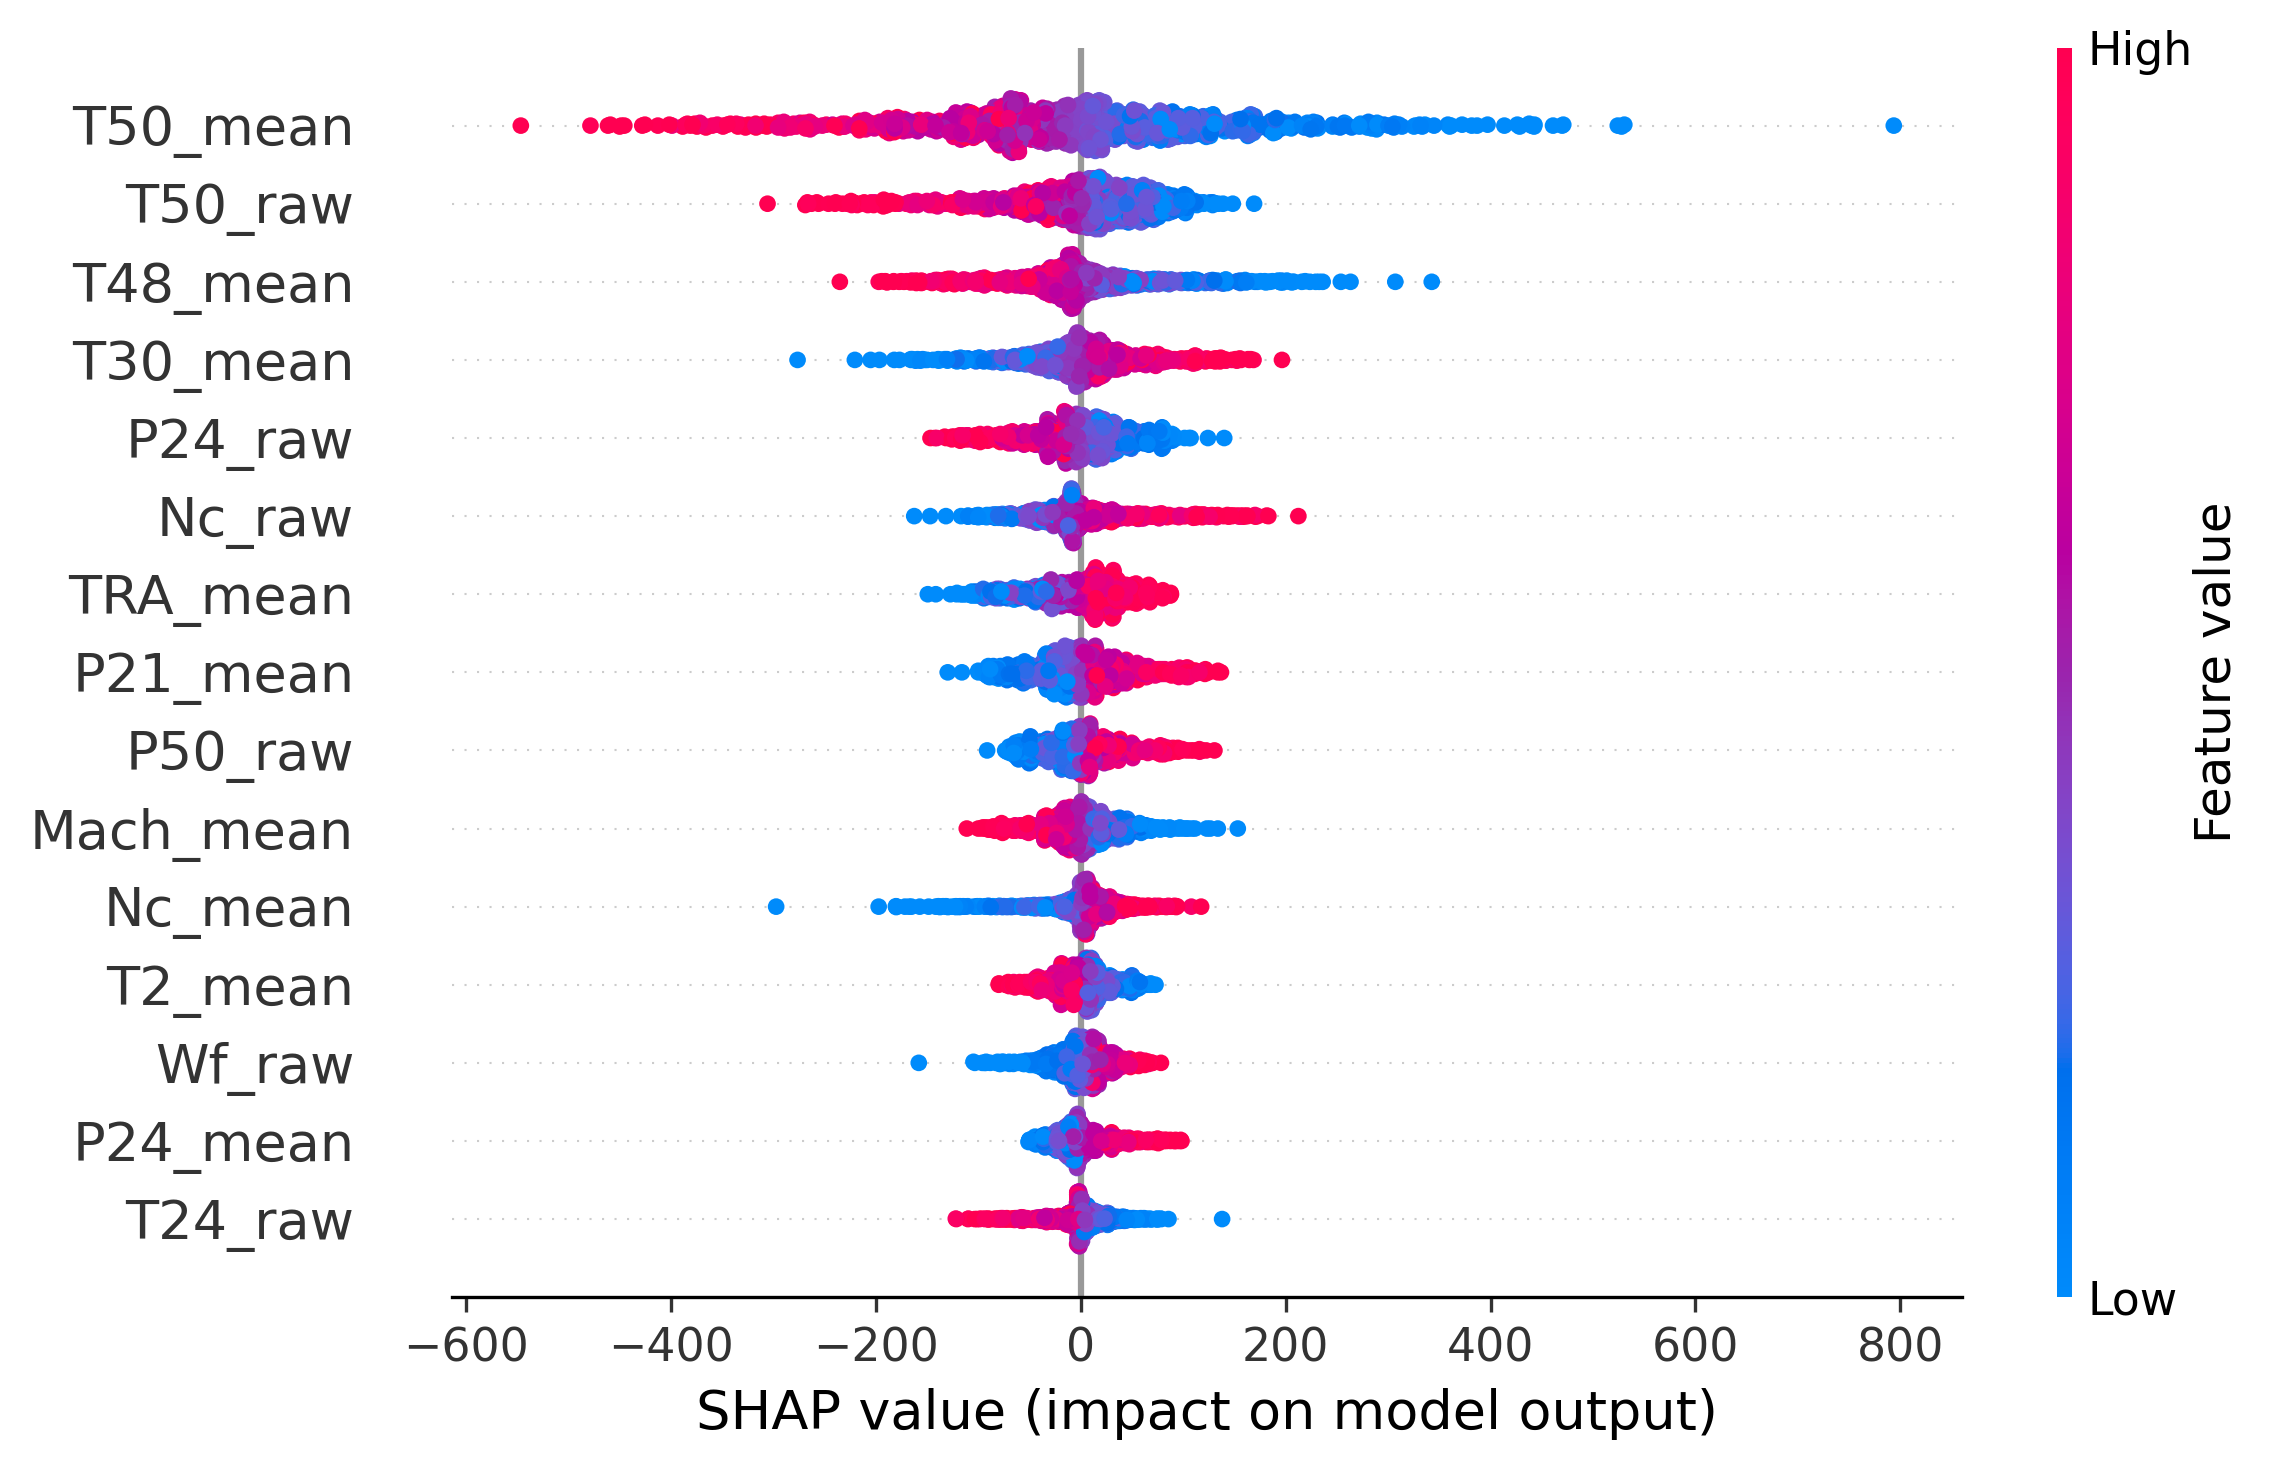

In [4]:
plt.figure(figsize=(10, 8))

# Criando o Summary Plot clássico com densidade de pontos
shap.summary_plot(
    shap_values, 
    features=explain_data, 
    feature_names=feature_names, 
    max_display=15, # Mostra apenas o Top 15 para não poluir
    show=False
)

# Ajustes de formatação acadêmica
# plt.title("Gráfico de Resumo SHAP – As 15 Variáveis ​​de Maior Impacto na Previsão da RUL", pad=20, fontsize=14)
fig = plt.gcf()
fig.set_size_inches(8, 5)
plt.tight_layout()

plt.savefig('fig/fig_shap_summary.png', bbox_inches='tight', dpi=300)
plt.show()

## 4. Importância Média Absoluta (Bar Plot)
Este gráfico mostra de forma quantitativa o impacto médio absoluto (em ciclos de RUL) de cada variável no modelo.

/tmp/ipykernel_61416/1272155290.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none o

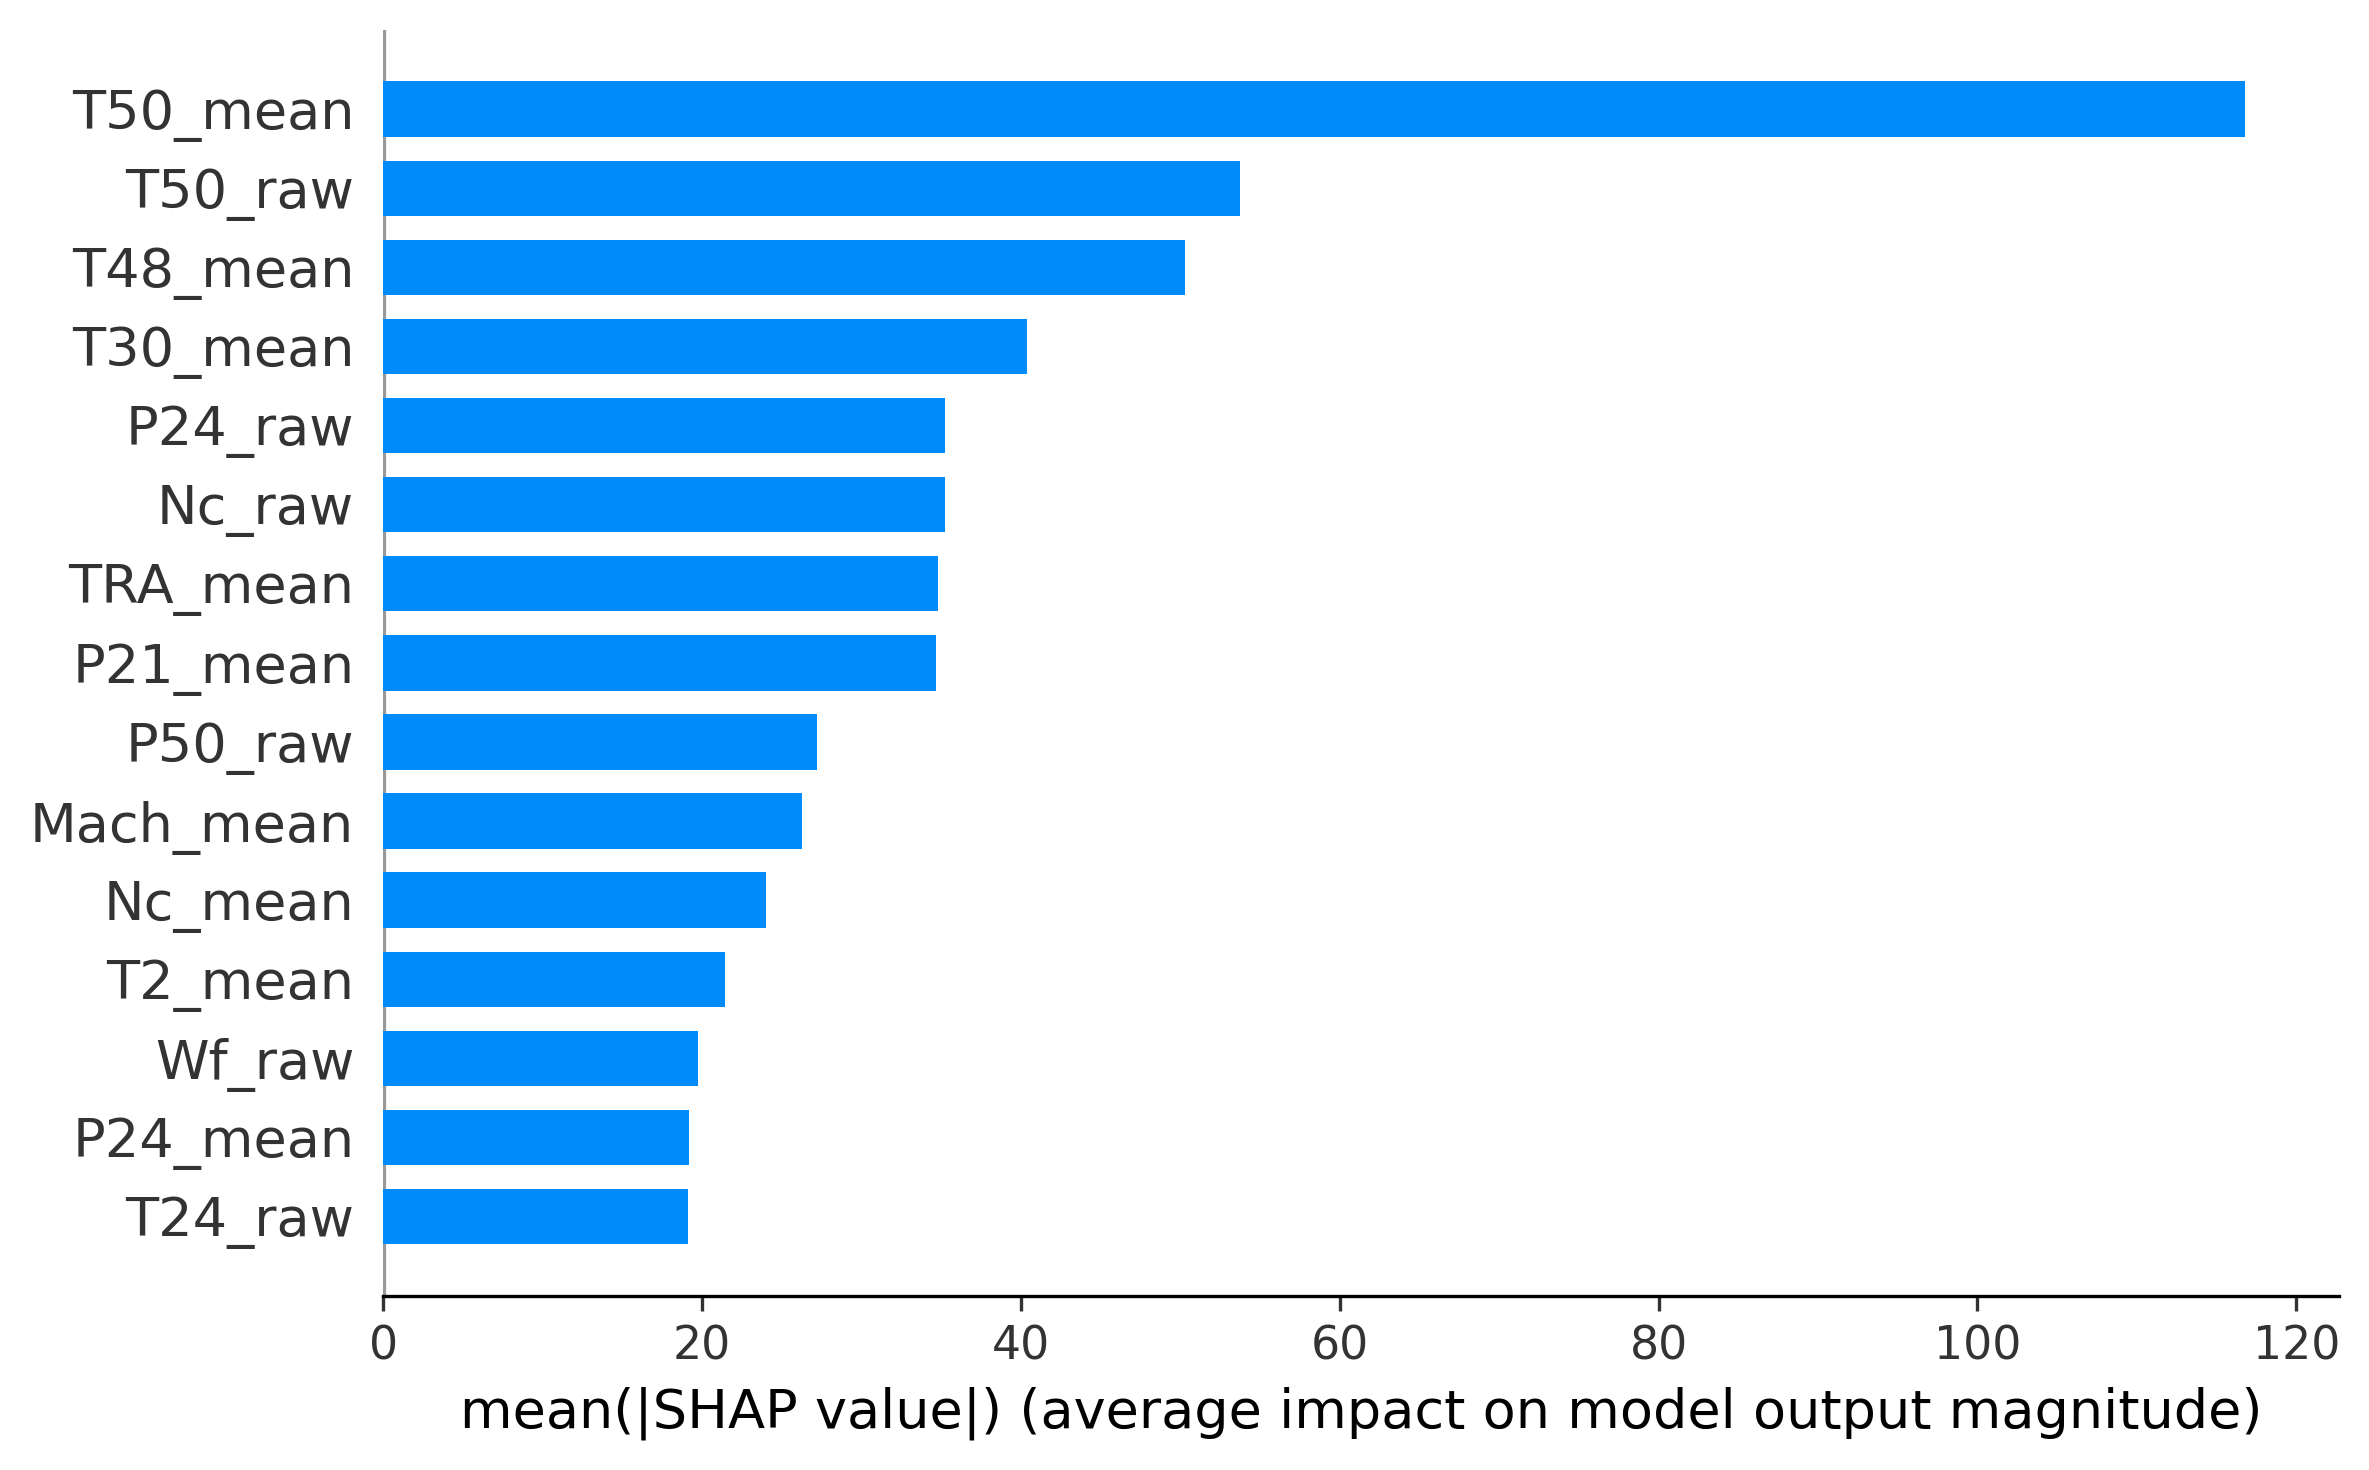

In [5]:
plt.figure(figsize=(8, 5))

shap.summary_plot(
    shap_values, 
    features=explain_data, 
    feature_names=feature_names, 
    plot_type="bar",
    max_display=15,
    show=False
)

# plt.title("Valor Absoluto Médio de SHAP (Importância da Característica)", pad=20, fontsize=14)
fig = plt.gcf()
fig.set_size_inches(8, 5)
plt.tight_layout()

plt.savefig('fig/fig_shap_bar.png', bbox_inches='tight', dpi=300)
plt.show()

## 5. Preparando a Função Wrapper e o KernelExplainer
Conforme o tutorial do SHAP, o `KernelExplainer` espera que o modelo receba um array 2D e devolva um vetor 1D. É preciso criar uma função `f(X)` para encapsular o `.predict()` do Keras.

In [6]:
# Wrapper exigido pelo SHAP KernelExplainer para modelos Keras
def f(X):
    # O modelo prevê e a gente "achata" a resposta para 1D
    return model.predict(X, verbose=0).flatten()

np.random.seed(42)

# Background de 50 amostras (como no tutorial do Census)
#ackground_data = df_X_test.iloc[:50, :]
background_data = shap.kmeans(df_X_test, 50)

print("Inicializando o KernelExplainer...")
# Usamos o KernelExplainer, que é agnóstico e perfeitamente estável para funções genéricas
kernel_explainer = shap.KernelExplainer(f, background_data)

Inicializando o KernelExplainer...


I0000 00:00:1789854008.482494   61518 service.cc:153] XLA service 0x721e54dc1980 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1789854008.482508   61518 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5050 Laptop GPU, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.9.0; DNN: 9.17.0)
I0000 00:00:1789854008.485800   61518 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1789854008.539494   61518 cuda_dnn.cc:461] Loaded cuDNN version 91700
I0000 00:00:1789854009.180149   61518 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


## 6. Explicando uma Predição Única (Local Interpretability)
Selecionando uma única linha do conjunto de teste (ex: a linha 299). O modelo fará a previsão de RUL para essa linha, e o SHAP vai decompor matematicamente quais variáveis empurraram o RUL para cima ou para baixo a partir do valor base.

In [7]:
# Selecionando uma instância para explicar
linha = 299
instancia = df_X_test.iloc[linha:linha+1, :]
rul_real = y_test_labels[linha]
rul_previsto = f(instancia.values)[0]

print(f"RUL Real do Motor: {rul_real}")
print(f"RUL Previsto pelo Modelo: {rul_previsto:.2f}")

print("\nCalculando SHAP para a instância")
shap_values_raw = kernel_explainer.shap_values(instancia,)

# Criando o objeto "Explanation" manualmente para não dar bug no gráfico
shap_obj = shap.Explanation(
    values=shap_values_raw[0], # Os pesos que empurram o RUL
    base_values=kernel_explainer.expected_value, # De onde a conta começa
    data=instancia.values[0], # Os valores reais dos sensores naquele momento
    feature_names=feature_names
)


RUL Real do Motor: 58.0
RUL Previsto pelo Modelo: 61.56

Calculando SHAP para a instância


  0%|          | 0/1 [00:00<?, ?it/s]

### 6.1 Waterfall Plot
O Gráfico de Cachoeira mostra a 'soma' das decisões. Ele parte do valor médio global esperado pelo modelo (no eixo X inferior) e vai somando ou subtraindo os impactos das features (em vermelho ou azul) até chegar na previsão final desta instância.

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

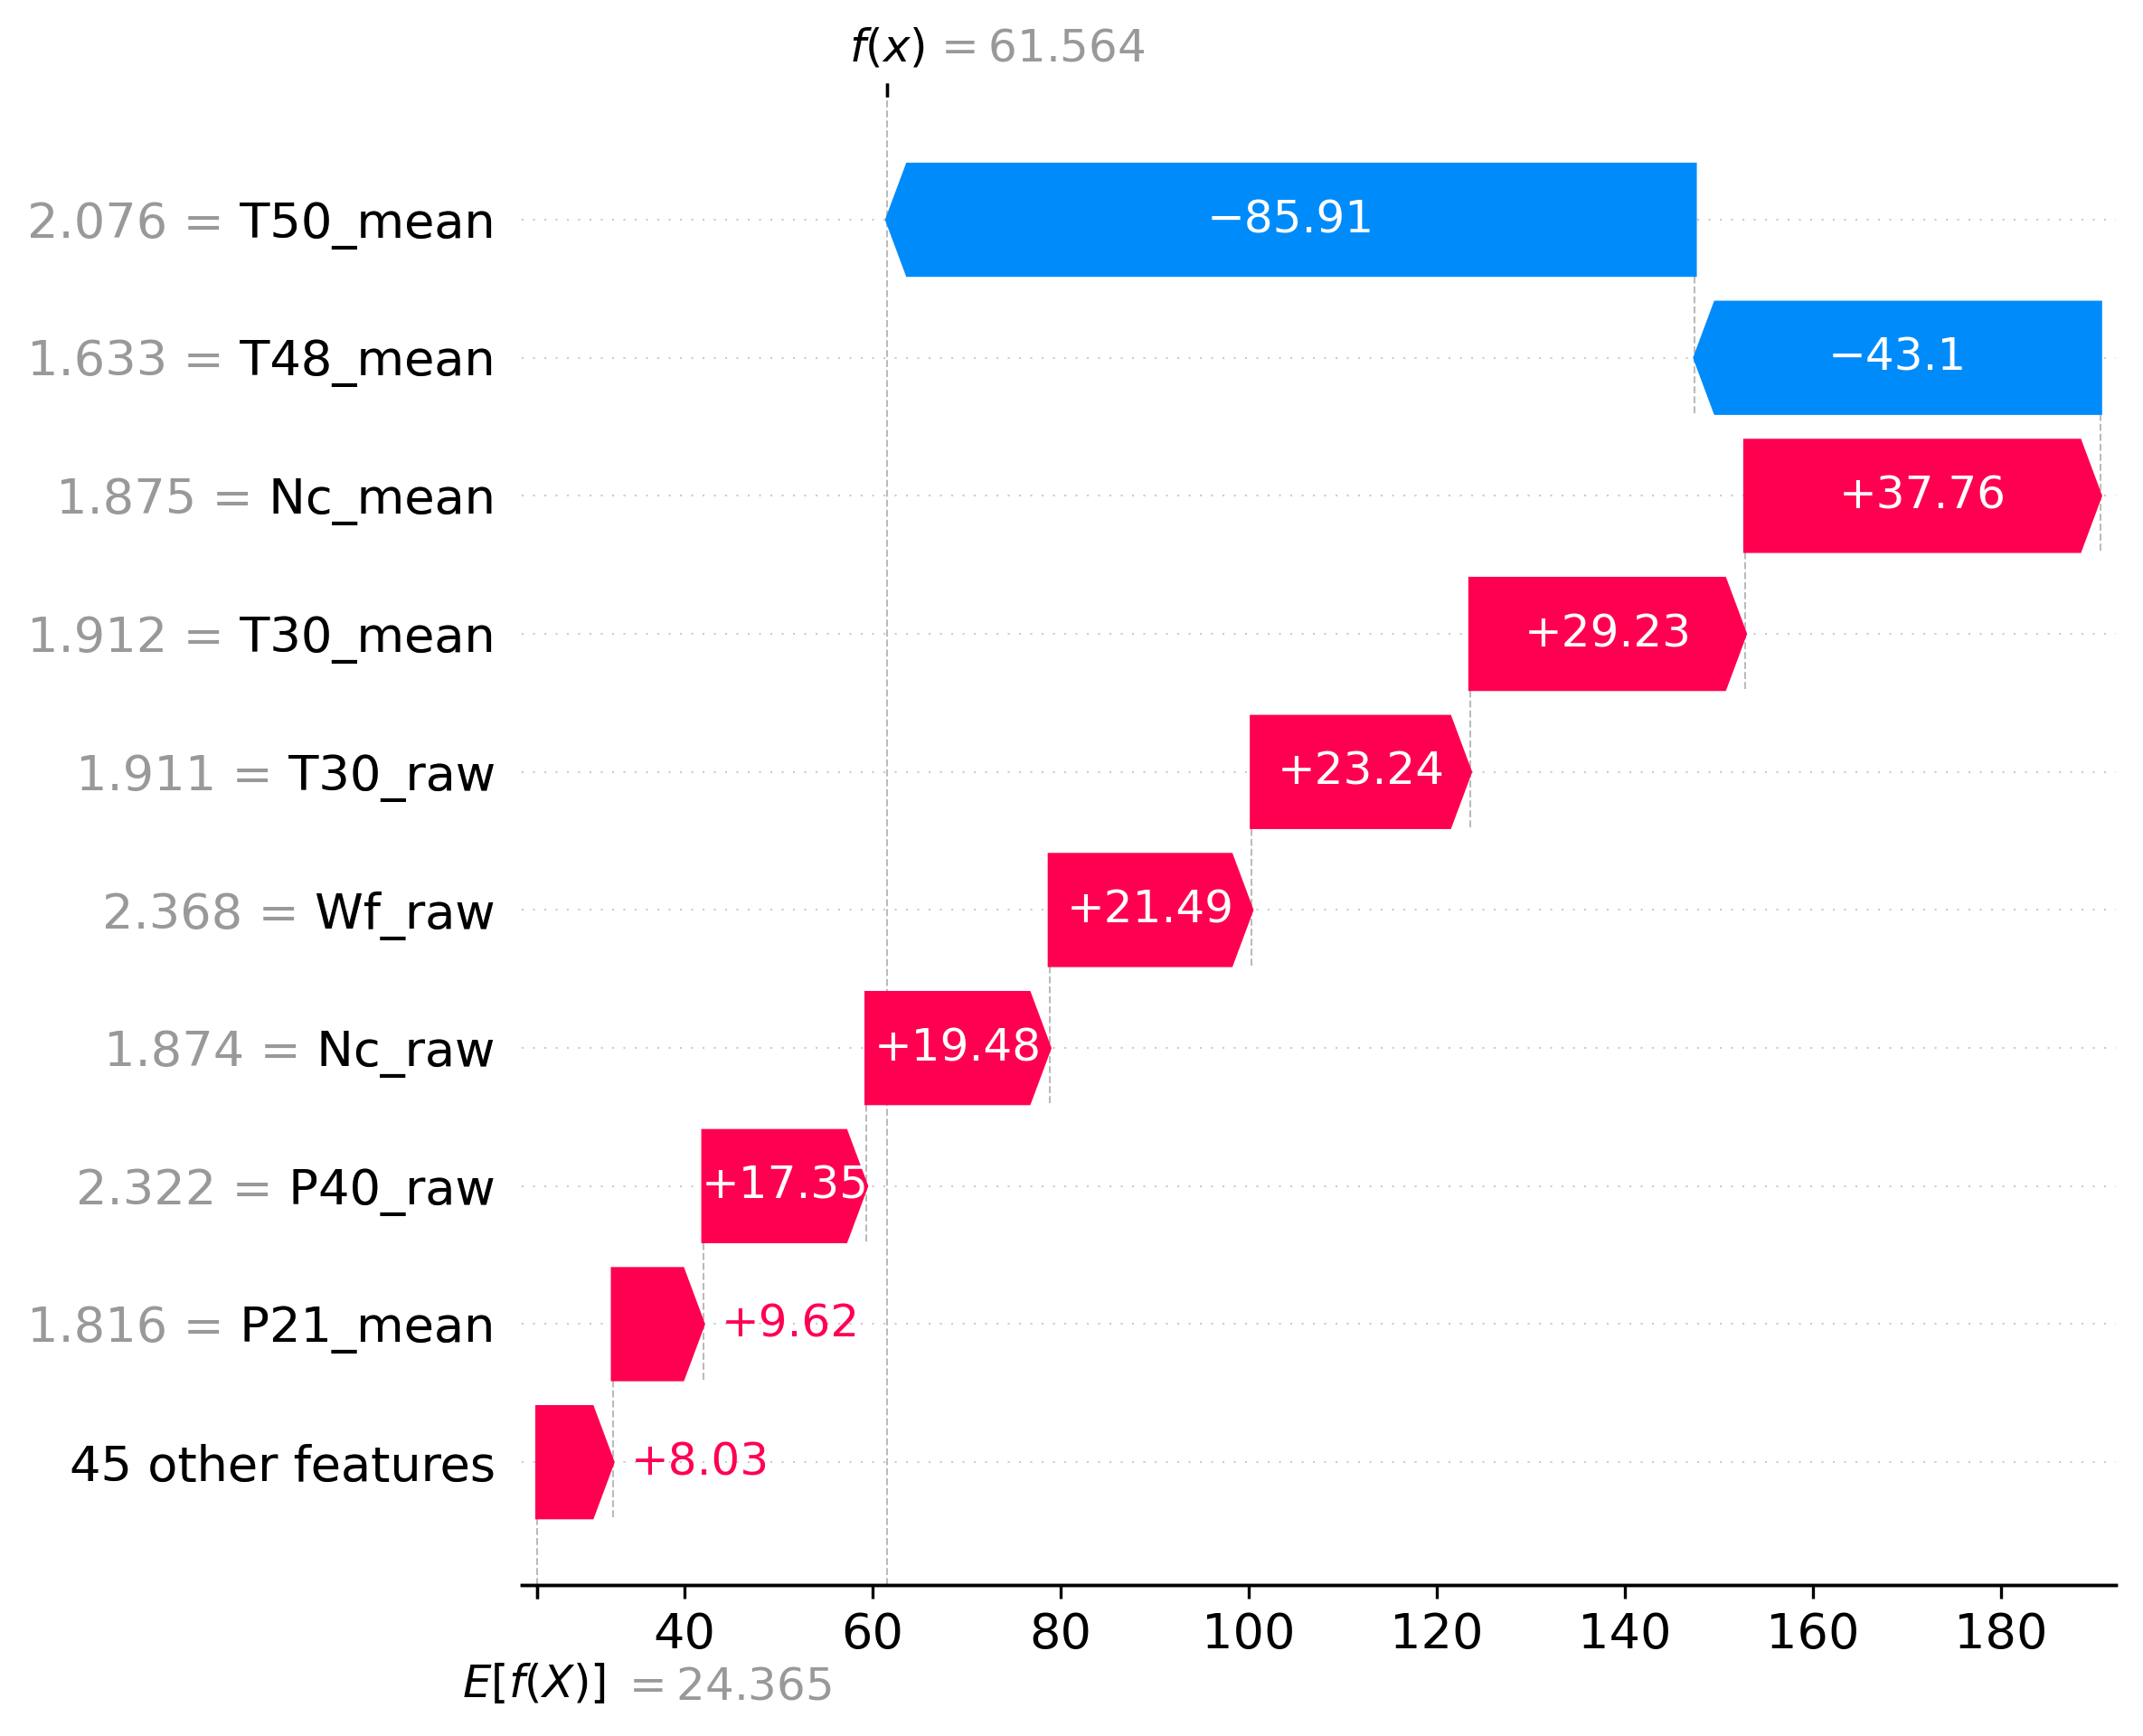

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
shap.plots.waterfall(shap_obj, show=False)
# plt.title(f"Waterfall Plot - Explicação da Instância {linha}")
plt.tight_layout()
plt.savefig('fig/fig_shap_waterfall.png')
plt.show()

### 6.2 Force Plot
O Gráfico de Força condensa a mesma informação em uma única linha interativa, muito útil para colocar abaixo de previsões em dashboards em tempo real.

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

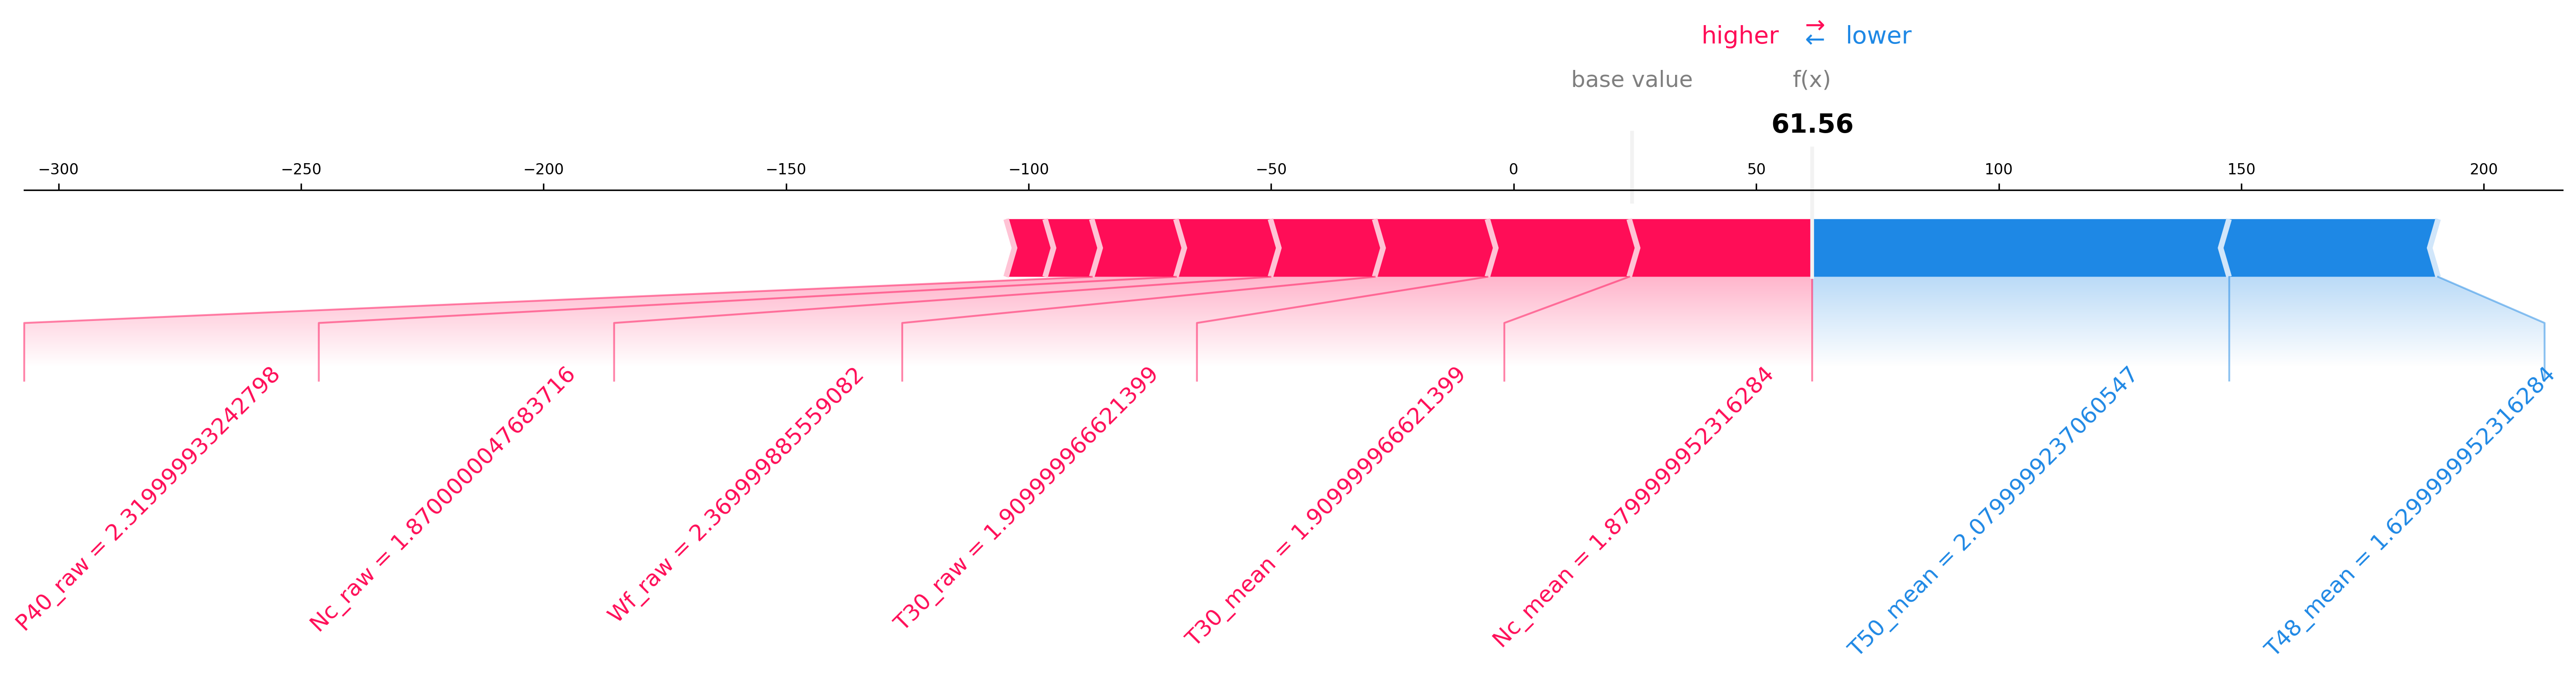

In [9]:
# Arredondando os valores para manter como números
instancia_arredondada = np.round(instancia.values[0], 2)

shap.force_plot(
    kernel_explainer.expected_value, 
    shap_values_raw[0], 
    instancia_arredondada, 
    feature_names=feature_names, 
    matplotlib=True, 
    show=False,
    figsize=(20, 5),             # Estica o gráfico para a tela toda
    text_rotation=45,            # Inclina os textos em 45 graus para não encavalar
    contribution_threshold=0.1   # Só escreve quem alterou a vida do motor em > 10%
)

# O SHAP cria uma figura própria por baixo dos panos
fig = plt.gcf()
# fig.suptitle(f"Force Plot - Explicação da Instância {linha}")

plt.tight_layout()
plt.savefig('fig/fig_shap_forceplot.png', bbox_inches='tight', dpi=300)
plt.show()
